## Project 1 - Aryel Leonard 

In [3]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import statsmodels.api as sm
import statsmodels.stats.api as sms
from scipy import stats

from IPython.display import Image

In [4]:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn import cluster, datasets
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.metrics import silhouette_samples
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [5]:
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
 
from sklearn.model_selection import train_test_split
from statistics import mean 
import statistics
from statistics import stdev

<font size="3"> 

Q1: The file *WHO_COVIDdata_SL.xlsx* contains COVID‑19 data for Sri Lanka from March 2020 to March 2021, before vaccines began to be administered. The variable *I* represents the daily prevalence of COVID‑19 cases, which is the series we aim to forecast. The variables *dR*, *R*, and *D* represent daily incident recovery cases, cumulative recovery cases, and daily death counts, respectively.
    
Conduct exploratory data analysis and discuss the seasonality, trend, autocorrelation, and partial autocorrelation plots. Suppose we want to determine whether a weekly forecasting model (predicting seven data points at a time) for prevalence cases (*I*) can be constructed. Use ARIMA and VAR models to compare 7‑day, 14‑day, and 21‑day forecasts. Optimize each model as much as possible using transformations, outlier corrections (values outside the 99% range of a normal distribution), and variable selection for the VAR model through best‑subset selection. For the optimal VAR model, you may set the maximum lag order \(p\) to 14 and use AIC as the selection criterion. Compare model performance using relative error, and when appropriate, compare the means of the relative errors or use relative‑error plots to evaluate the results.


Reference:  
Dinesh B. Ekanayake, Iduruwage Harsha Premarathna, Elizabeth Hansen, *Estimating transmission parameters and the reproduction number: COVID‑19 in Sri Lanka as a case study*, Mathematical Medicine and Biology: A Journal of the IMA, Volume 42, Issue 3, September 2025, Pages 289–307, [https://doi.org/10.1093/imammb/dqaf005](https://doi.org/10.1093/imammb/dqaf005)

In [6]:
# Read dataset
df_COVID=pd.read_excel('WHO_COVIDdata_SL.xlsx',sheet_name='Sheet1',usecols='A:E',
                    na_values=['nan'])
# Find the rows with missing data
print(df_COVID[df_COVID.isnull().any(axis=1)])
#df_COVID=df_COVID.ffill()

df_COVID.head(2)

Empty DataFrame
Columns: [Date, dR, R, D, I]
Index: []


,Date,dR,R,D,I
0,2020-03-01,0,0,0,5
1,2020-03-02,0,0,0,5


## **Explanatory Data Analysis**

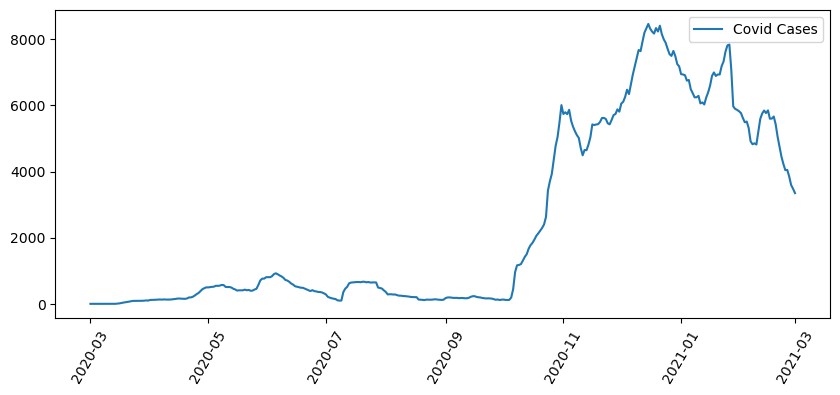

In [5]:
df_COVID=df_COVID.set_index('Date')

# Setting figure size
plt.figure(figsize=(10,4))

# Plot original sales data
plt.plot(df_COVID['I'], label="Covid Cases")
# Rotate xlabels
plt.xticks(rotation=60)
# Add legends
plt.legend()
#display the plot
plt.show()

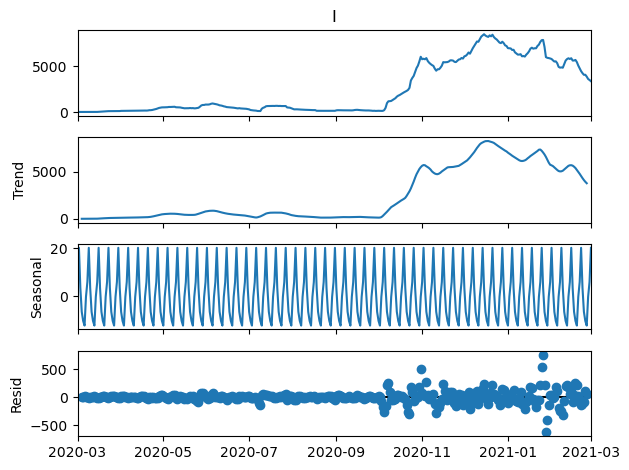

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

# model{“additive”, “multiplicative”}
decomposed_data = seasonal_decompose(df_COVID['I'], model='additive') 

# Plot decomposed data
decomposed_data.plot()
# Display the plot
plt.show()

In [7]:
Z=df_COVID['I']

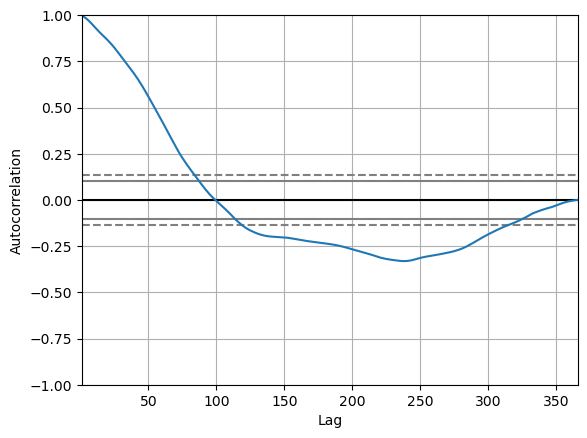

In [8]:
from pandas.plotting import autocorrelation_plot
# Plot using pandas function

autocorrelation_plot(Z) 
plt.show()

The EDA shows the time series behaviour of the prevalence cases (I) through its trend, seasonality and autocorrelation structure. EDA shows that I has a clear time series structure. The decomposition shows that the time series plots are non-stationary, has a clear upwards trend and contains seasonality. The seasonal component indicates that there is a recurring periodic behaviour with presumably weekly reporting cycles. The oscillation are constant and repeating thus pointing towards using differencing and SARIMA.The ACF plot indicates that the data declines very slowly suggesting non-stationarity. 

In [9]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(Z)
print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])

ADF Statistic: -1.296959
p-value: 0.630563


The Augmented Dickey–Fuller test yields a p‑value greater than 0.05 indicating that we fail to reject the null hypothesis. This matches the autocorrelation plot which shows a slow ACF decay with the series is non-stationary and has a trend.   

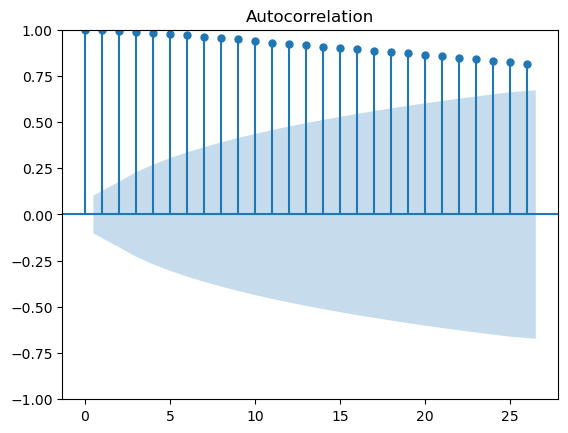

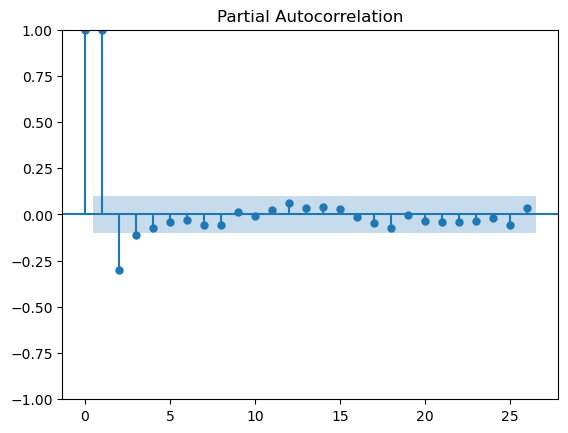

In [10]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plot_acf(Z)
plot_pacf(Z,method='ywm')
plt.show()

### Selection of ARIMA and SARIMA models

Suggested non-seasonal ARIMA orders

- **Autoregressive order $p$:** **2**  
  - PACF has a clearly non‑negligible negative spike at lag 2 ($\approx -0.30$), then becomes very small—this is a “cutoff” pattern for an $\text{AR}(2)$ component.

- **Integrated order $d$:** **1**  
  - The ACF shows extremely slow decay.Thus, a first difference is used.

- **Moving average order $q$:** **0**  
  - There is no sharp cutoff in the ACF at low lags; instead we see slow decay. That points more toward AR structure than MA at the non‑seasonal level, so $\text{MA}$ terms are not strongly suggested.

So a reasonable non‑seasonal starting point is: $ \text{ARIMA}(2,1,0) $

---


In [12]:
from statsmodels.tsa.arima.model import ARIMA

#  Define ARIMA model order (p, d, q)
# p: Autoregressive order (number of lagged observations)
# d: Integrated order (degree of differencing for stationarity)
# q: Moving Average order (number of lagged forecast errors)
order = (2, 1, 0) 

k=7
data=Z[:-k-1]

# 3. Fit the ARIMA model
model = ARIMA(data, order=order)
result = model.fit()

# Print a summary of the model (optional)
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      I   No. Observations:                  358
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -2232.732
Date:                Mon, 11 May 2026   AIC                           4471.464
Time:                        18:42:06   BIC                           4483.097
Sample:                    03-01-2020   HQIC                          4476.091
                         - 02-21-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4911      0.024     20.093      0.000       0.443       0.539
ar.L2          0.0522      0.039      1.323      0.186      -0.025       0.130
sigma2      1.592e+04    538.222     29.573      0.0

C:\Users\aryel\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\aryel\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\aryel\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Since we have high heteroskedasticity, we use Box-Cox transformations to transform the data. 

## **Box-Cox Transformations**

In [13]:
# Box-Cox transformations

transformed_data, best_lambda = stats.boxcox(data)

print(f"Optimal Lambda: {best_lambda}")

Optimal Lambda: 0.10605341687164752


This value falls between the range of **$ 0 < \lambda < 1$**  which shows a gentle variance reduction. 

In [14]:
from statsmodels.tsa.arima.model import ARIMA

order = (2, 1, 0) 

# 3. Fit the ARIMA model
model = ARIMA(transformed_data, order=order)
result = model.fit()

# Print a summary of the model (optional)
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  358
Model:                 ARIMA(2, 1, 0)   Log Likelihood                  44.340
Date:                Mon, 11 May 2026   AIC                            -82.680
Time:                        18:42:09   BIC                            -71.047
Sample:                             0   HQIC                           -78.053
                                - 358                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4403      0.021     21.436      0.000       0.400       0.481
ar.L2          0.0487      0.030      1.621      0.105      -0.010       0.108
sigma2         0.0456      0.001     56.452      0.0

This did not assist with the heteroskedasticity with the probability still remaining at 0, though the AIC went lower than the previous model without Box - Cox transformation thus we then turn to another model, SARIMA with the Box Cox transformation. From our EDA we saw that the ACF showed a trend of seasonailty thus SARIMA should be a better model. 

### **SARIMA Model**


In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = sm.tsa.statespace.SARIMAX(transformed_data,
                                order=(2, 1, 0),
                                seasonal_order=(1, 1, 0, 7),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

result = model.fit()

# Print a summary of the model (optional)
print(result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  358
Model:             SARIMAX(2, 1, 0)x(1, 1, 0, 7)   Log Likelihood                   0.426
Date:                           Mon, 11 May 2026   AIC                              7.148
Time:                                   18:42:13   BIC                             22.476
Sample:                                        0   HQIC                            13.255
                                           - 358                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5046      0.034     14.797      0.000       0.438       0.571
ar.L2         -0.0083      0.059     -0.140

We see that the SARIMA model did not improve the Heteroskedasticity probability nor the Jarque-bera probability. Thus we see if the dataset has any outliers that needs to be removed in order for a better model to be obtained. 

###  **Outlier Calculations** 

In [16]:
# Get standardized residuals
std_resid = result.resid / np.std(result.resid)

# Identify extreme outliers covering values outside the 99.99% range of a normal distribution
outliers = data[np.abs(std_resid) > 3.89]
print(f"Detected outliers:\n{outliers}")

Detected outliers:
Date
2020-03-01      5
2020-07-10    359
2020-07-17    664
2020-10-06    454
Name: I, dtype: int64


In [17]:
#Replace outliers with rolling median (recommended for time series)
outlier_mask = np.abs(std_resid) > 3.89

rolling_median = data.rolling(window=5, center=True).median()
data_cleaned = data.copy()
data_cleaned.loc[outlier_mask] = rolling_median[outlier_mask]

# Replace the missing values
missing_indices = data_cleaned[data_cleaned.isna()].index
data_cleaned[missing_indices]=data[missing_indices]

In [17]:
np.shape(data_cleaned)

(358,)

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = sm.tsa.statespace.SARIMAX(transformed_data,
                                order=(2, 1, 0),
                                seasonal_order=(1, 1, 0, 7),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

result = model.fit()

# Print a summary of the model (optional)
print(result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  358
Model:             SARIMAX(2, 1, 0)x(1, 1, 0, 7)   Log Likelihood                   0.426
Date:                           Mon, 11 May 2026   AIC                              7.148
Time:                                   18:43:26   BIC                             22.476
Sample:                                        0   HQIC                            13.255
                                           - 358                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5046      0.034     14.797      0.000       0.438       0.571
ar.L2         -0.0083      0.059     -0.140

In [20]:
from scipy.special import inv_boxcox

scaled_A1=result.forecast(k)
# Revert transformed data using the lambda found earlier
A1 = inv_boxcox(scaled_A1, best_lambda)

A2=Z.iloc[-k:].values
print('Relative error')
Error_SARIMAX = abs(A1-A2)/A2
for x in Error_SARIMAX:
    print(f"{x:.3f}")

Relative error
0.109
0.115
0.146
0.251
0.324
0.323
0.320


In [21]:
transformed_data = pd.DataFrame(transformed_data, columns=['I'])

Removing the outliers did not help improve the heteroskedasticity and jarque-bera results thus we move on to power transformations to see if it stabilizes the variance. 

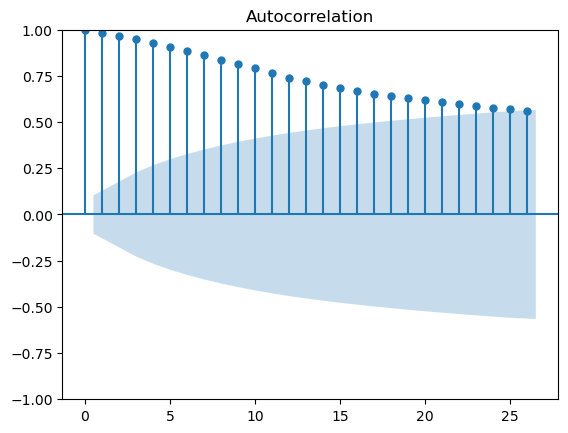

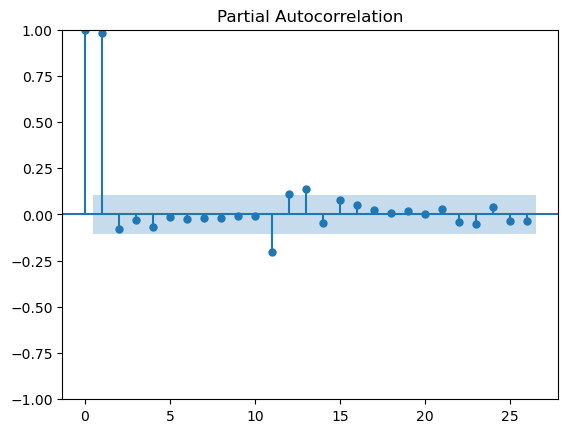

In [22]:
transformed_data['SQRT_I'] = np.sqrt(transformed_data['I'])

plot_acf(transformed_data.SQRT_I)
plot_pacf(transformed_data.SQRT_I, method='ywm')

plt.show()

In [23]:
from statsmodels.tsa.arima.model import ARIMA

k= 7
data = transformed_data.SQRT_I[:-k-1]

order = (2, 1, 0) 

# 3. Fit the ARIMA model
model = ARIMA(data, order=order)
result = model.fit()

# Print a summary of the model (optional)
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                 SQRT_I   No. Observations:                  350
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 522.052
Date:                Mon, 11 May 2026   AIC                          -1038.103
Time:                        18:43:39   BIC                          -1026.538
Sample:                             0   HQIC                         -1033.499
                                - 350                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2707      0.014     18.746      0.000       0.242       0.299
ar.L2          0.0158      0.016      1.010      0.312      -0.015       0.046
sigma2         0.0029   5.28e-05     55.623      0.0

Transforming the forecasted value did not help with improving heteroskedasticity nor jarque-bera hence indicating that another model may be needed. Though comparing the AIC to previous models this models AIC is better due to its lower value of -1039. Thus we will now use this for forecasting. We will then try Var models and compare their relative error to determine which values produce less error based on previous values. 

In [24]:
A1=result.forecast(k)
A2=transformed_data['SQRT_I'].iloc[-k:].values
print('Relative error')
Error_ARIMA7 = abs(A1-A2)/A2
for x in Error_ARIMA7:
    print(f"{x:.3f}")

Relative error
0.000
0.004
0.004
0.003
0.007
0.014
0.019


In [25]:
k=14
A1=result.forecast(k)
A2=transformed_data['SQRT_I'].iloc[-k:].values
print('Relative error')
Error_ARIMA14 = abs(A1-A2)/A2
for x in Error_ARIMA14:
    print(f"{x:.3f}")

Relative error
0.017
0.018
0.011
0.005
0.002
0.001
0.002
0.001
0.004
0.004
0.003
0.007
0.014
0.019


In [26]:
k=21
A1=result.forecast(k)
A2=transformed_data['SQRT_I'].iloc[-k:].values
print('Relative error')
Error_ARIMA21 = abs(A1-A2)/A2
for x in Error_ARIMA21:
    print(f"{x:.3f}")

Relative error
0.002
0.004
0.006
0.006
0.009
0.016
0.018
0.017
0.018
0.011
0.005
0.002
0.001
0.002
0.001
0.004
0.004
0.003
0.007
0.014
0.019


In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = sm.tsa.statespace.SARIMAX(data,
                                order=(2, 1, 0),
                                seasonal_order=(1, 1, 0, 7),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

result = model.fit()

# Print a summary of the model (optional)
print(result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            SQRT_I   No. Observations:                  350
Model:             SARIMAX(2, 1, 0)x(1, 1, 0, 7)   Log Likelihood                 509.447
Date:                           Mon, 11 May 2026   AIC                          -1010.894
Time:                                   18:43:47   BIC                           -995.661
Sample:                                        0   HQIC                         -1004.819
                                           - 350                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3820      0.025     15.284      0.000       0.333       0.431
ar.L2          0.0224      0.030      0.751

In [28]:
k=7
A1=result.forecast(k)
A2=transformed_data['SQRT_I'].iloc[-k:].values
print('Relative error')
Error_SARIMA7 = abs(A1-A2)/A2
for x in Error_SARIMA7:
    print(f"{x:.3f}")

Relative error
0.001
0.005
0.004
0.006
0.013
0.020
0.023


In [29]:
k=14
A1=result.forecast(k)
A2=transformed_data['SQRT_I'].iloc[-k:].values
print('Relative error')
Error_SARIMA14 = abs(A1-A2)/A2
for x in Error_SARIMA14:
    print(f"{x:.3f}")

Relative error
0.018
0.019
0.011
0.007
0.008
0.007
0.005
0.004
0.008
0.007
0.011
0.020
0.027
0.032


In [30]:
k=21
A1=result.forecast(k)
A2=transformed_data['SQRT_I'].iloc[-k:].values
print('Relative error')
Error_SARIMA21 = abs(A1-A2)/A2
for x in Error_SARIMA21:
    print(f"{x:.3f}")

Relative error
0.002
0.005
0.006
0.008
0.015
0.022
0.021
0.020
0.022
0.014
0.012
0.014
0.014
0.015
0.014
0.018
0.017
0.020
0.028
0.035
0.039


### **VAR Models**

In [31]:
# Import Statsmodels
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic
import statsmodels.tsa.vector_ar as stattsa

In [32]:
# Selected variables

data = df_COVID[['R', 'D', 'I']]

model = VAR(data)
results = model.fit(maxlags=14, ic='aic')
lag_order = results.k_ar
print('Optimal Lag: ',lag_order,'\n')

Optimal Lag:  13 



C:\Users\aryel\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [33]:
# Perform residual autocorrelation test. nlags must be greater than optimal lags
whiteness_results = results.test_whiteness(nlags=14)

# Display the WhitenessTestResults
print(whiteness_results.summary())
print(f"P-value: {whiteness_results.pvalue}")

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 14 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         52.11          16.92   0.000  9
----------------------------------------
P-value: 4.316523289157458e-08


In [34]:
# Perform the normality test
normality_results = results.test_normality(signif=0.05)

# Display the results summary
print(normality_results.summary())

normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     1.333e+04          12.59   0.000  6
----------------------------------------


In [35]:
k=7
A3=results.forecast(data.values[:-k], k)
A4=df_COVID.iloc[-k:,1].values
print('Relative error')
Error_VAR7 = abs(A3[:,0]-A4)/A4

print(Error_VAR7)

Relative error
[0.00135979 0.00185745 0.00505504 0.0057321  0.00645628 0.00850826
 0.01022917]


In [36]:
k=14
A3=results.forecast(data.values[:-k], k)
A4=df_COVID.iloc[-k:,1].values
print('Relative error')
Error_VAR14 = abs(A3[:,0]-A4)/A4

print(Error_VAR14)

Relative error
[0.00363978 0.00344102 0.00035698 0.00139449 0.00052271 0.00110463
 0.00047515 0.00183454 0.00438873 0.00960805 0.01164562 0.01267397
 0.01595965 0.01983964]


In [37]:
k=21
A3=results.forecast(data.values[:-k], k)
A4=df_COVID.iloc[-k:,1].values
print('Relative error')
Error_VAR21 = abs(A3[:,0]-A4)/A4

print(Error_VAR21)

Relative error
[0.00229953 0.00069302 0.00312585 0.00326478 0.00012038 0.00195825
 0.00175242 0.00571737 0.00724838 0.00655312 0.00685338 0.00920899
 0.0106484  0.01204457 0.01225406 0.01198515 0.00843384 0.0080934
 0.00854237 0.00688215 0.00417149]


In [39]:
Error_ARIMA7.values
Arr=np.column_stack((Error_ARIMA7.values, Error_SARIMA7, Error_VAR7))
print(' ARIMA  SARIMA   VAR')
with np.printoptions(precision=3, suppress=True):
    print(Arr)

 ARIMA  SARIMA   VAR
[[0.    0.001 0.001]
 [0.004 0.005 0.002]
 [0.004 0.004 0.005]
 [0.003 0.006 0.006]
 [0.007 0.013 0.006]
 [0.014 0.02  0.009]
 [0.019 0.023 0.01 ]]


In [40]:
Error_ARIMA14.values
Arr=np.column_stack((Error_ARIMA14.values, Error_SARIMA14, Error_VAR14))
print(' ARIMA  SARIMA   VAR')
with np.printoptions(precision=3, suppress=True):
    print(Arr)

 ARIMA  SARIMA   VAR
[[0.017 0.018 0.004]
 [0.018 0.019 0.003]
 [0.011 0.011 0.   ]
 [0.005 0.007 0.001]
 [0.002 0.008 0.001]
 [0.001 0.007 0.001]
 [0.002 0.005 0.   ]
 [0.001 0.004 0.002]
 [0.004 0.008 0.004]
 [0.004 0.007 0.01 ]
 [0.003 0.011 0.012]
 [0.007 0.02  0.013]
 [0.014 0.027 0.016]
 [0.019 0.032 0.02 ]]


In [41]:
Error_ARIMA21.values
Arr=np.column_stack((Error_ARIMA21.values, Error_SARIMA21, Error_VAR21))
print(' ARIMA  SARIMA   VAR')
with np.printoptions(precision=3, suppress=True):
    print(Arr)

 ARIMA  SARIMA   VAR
[[0.002 0.002 0.002]
 [0.004 0.005 0.001]
 [0.006 0.006 0.003]
 [0.006 0.008 0.003]
 [0.009 0.015 0.   ]
 [0.016 0.022 0.002]
 [0.018 0.021 0.002]
 [0.017 0.02  0.006]
 [0.018 0.022 0.007]
 [0.011 0.014 0.007]
 [0.005 0.012 0.007]
 [0.002 0.014 0.009]
 [0.001 0.014 0.011]
 [0.002 0.015 0.012]
 [0.001 0.014 0.012]
 [0.004 0.018 0.012]
 [0.004 0.017 0.008]
 [0.003 0.02  0.008]
 [0.007 0.028 0.009]
 [0.014 0.035 0.007]
 [0.019 0.039 0.004]]


The normality test was less than 0.05 thus residuals are not normal. Further the whiteness test was also 0 which means the residuals still contain aautocorrelation,thus the residuals are not random. The values for ARIMA and VAR are quite close though on average the VAR models did just slightly better. The values for SARIMA on average were higher than both VAR and ARIMA models. Thus we then run best subset selection in order to get an optimal VAR model.Further, using all variables in the model led to an error saying the system istoo colinear or too overparameterized. Dropping redundant variables or differencing the values did not assist. Thus, I tried removing the R from the model and VAR relative errors wre extremely high. Next I removed dR from the model and the relative errors reduced significantly thus this model was used.  

In [42]:
import itertools
k=7

# Best subset by minimizing sum of residuals
def best_subset_selection_SumRes(X, y, k):
    best_model = None
    best_rss = float('inf')

    for combo in itertools.combinations(X.columns, k):
        X0=X[list(combo)]; 
        # Add if wish to select the variables using centered models
        # X0 = sm.add_constant(X0)
        model = sm.OLS(y, X0).fit()
        rss = ((model.predict(X[list(combo)]) - y) ** 2).sum()

        if rss < best_rss:
            best_model = model
            best_rss = rss

    return best_model

In [43]:
# BIC model
X = df_COVID.iloc[:, 0:3] 

y = df_COVID.iloc[:, 3]  

p0=1; p1=3; n=p1-p0; 
M=np.zeros([n,1])


for j in range(p0,p1):
    best_model = best_subset_selection_SumRes(X, y, j)
    M[j-p0] = best_model.bic

min_BIC = np.min(M)
min_index = np.argmin(M)

results = best_subset_selection_SumRes(X, y, min_index+p0)
print(results.params)
print(results.bic)
print(results.rsquared_adj)

dR    8.790715
dtype: float64
6438.349734342387
0.8165317847373238


Since the best subset selction only chose 1 variable then VAR optimal is no longer valid since the Var model requires at leats two endogenous variables. Thus the VAR step is no longer valid as a VAR comparison. 

In [44]:
data=data.astype(float)
data

,R,D,I
Date,,,
2020-03-01,0.0,0.0,5.0
2020-03-02,0.0,0.0,5.0
2020-03-03,0.0,0.0,5.0
2020-03-04,0.0,0.0,5.0
2020-03-05,0.0,0.0,5.0
...,...,...,...
2021-02-25,76961.0,457.0,4049.0
2021-02-26,77625.0,459.0,3849.0
2021-02-27,78373.0,464.0,3593.0


In [45]:
from statsmodels.tsa.statespace.varmax import VARMAX
k=7

model = VARMAX(data[:-k-1], order=(8, 1))
results = model.fit(maxiter=100, disp=False)

C:\Users\aryel\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\aryel\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\aryel\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:373: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\aryel\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [47]:
forecast = results.get_forecast(steps=k)

# Access forecasted values
print(forecast.predicted_mean)

                       R           D            I
2021-02-22  74430.470505  394.479873  5167.933143
2021-02-23  74163.466050  367.062071  4290.235181
2021-02-24  76443.739922  379.265715  4617.317258
2021-02-25  74835.359461  388.174616  6539.178490
2021-02-26  74714.523778  389.642923  6947.310701
2021-02-27  75218.231396  380.622221  6378.718213
2021-02-28  75688.906087  366.251246  5656.256739


In [48]:
k=7
A5=forecast.predicted_mean['I']

A6=df_COVID.iloc[-k:,3].values
print('Relative error')
Error_VAR_AM7 = abs(A5-A6)/A6

print(Error_VAR_AM7)

Relative error
2021-02-22    0.223179
2021-02-23    0.061414
2021-02-24    0.140360
2021-02-25    0.698929
2021-02-26    0.933568
2021-02-27    0.833492
2021-02-28    0.688939
Freq: D, Name: I, dtype: float64


In [49]:
forecast = results.get_forecast(steps=14)

# Access forecasted values
print(forecast.predicted_mean)

                       R           D            I
2021-02-22  74430.470505  394.479873  5167.933143
2021-02-23  74163.466050  367.062071  4290.235181
2021-02-24  76443.739922  379.265715  4617.317258
2021-02-25  74835.359461  388.174616  6539.178490
2021-02-26  74714.523778  389.642923  6947.310701
2021-02-27  75218.231396  380.622221  6378.718213
2021-02-28  75688.906087  366.251246  5656.256739
2021-03-01  76083.741311  351.159219  5027.469538
2021-03-02  76282.785687  339.261459  4850.311395
2021-03-03  75795.973656  341.707491  5959.040141
2021-03-04  74647.723660  346.447317  7752.196869
2021-03-05  75065.453077  335.739620  6699.688978
2021-03-06  75344.302838  325.715938  6281.934102
2021-03-07  75025.233664  316.499807  6173.645176


In [50]:
k=14
A7=forecast.predicted_mean['I']

A8=df_COVID.iloc[-k:,3].values
print('Relative error')
Error_VAR_AM14 = abs(A7-A8)/A8

print(Error_VAR_AM14)

Relative error
2021-02-22    0.076495
2021-02-23    0.233750
2021-02-24    0.184364
2021-02-25    0.205601
2021-02-26    0.376250
2021-02-27    0.344020
2021-02-28    0.272785
2021-03-01    0.189934
2021-03-02    0.199978
2021-03-03    0.471731
2021-03-04    1.014081
2021-03-05    0.864650
2021-03-06    0.805672
2021-03-07    0.843429
Freq: D, Name: I, dtype: float64


In [51]:
forecast = results.get_forecast(steps=21)

# Access forecasted values
print(forecast.predicted_mean)

                       R           D            I
2021-02-22  74430.470505  394.479873  5167.933143
2021-02-23  74163.466050  367.062071  4290.235181
2021-02-24  76443.739922  379.265715  4617.317258
2021-02-25  74835.359461  388.174616  6539.178490
2021-02-26  74714.523778  389.642923  6947.310701
2021-02-27  75218.231396  380.622221  6378.718213
2021-02-28  75688.906087  366.251246  5656.256739
2021-03-01  76083.741311  351.159219  5027.469538
2021-03-02  76282.785687  339.261459  4850.311395
2021-03-03  75795.973656  341.707491  5959.040141
2021-03-04  74647.723660  346.447317  7752.196869
2021-03-05  75065.453077  335.739620  6699.688978
2021-03-06  75344.302838  325.715938  6281.934102
2021-03-07  75025.233664  316.499807  6173.645176
2021-03-08  74755.694737  308.722096  6072.695910
2021-03-09  74466.133837  302.724819  6156.064077
2021-03-10  73979.064373  298.380116  6585.142080
2021-03-11  73381.458655  294.494547  7162.566507
2021-03-12  73047.713417  287.674076  7174.868525


In [52]:
k=21
A5=forecast.predicted_mean['I']

A6=df_COVID.iloc[-k:,3].values
print('Relative error')
Error_VAR_AM21 = abs(A5-A6)/A6

print(Error_VAR_AM21)

Relative error
2021-02-22    0.072853
2021-02-23    0.174479
2021-02-24    0.173708
2021-02-25    0.136655
2021-02-26    0.189404
2021-02-27    0.106264
2021-02-28    0.032457
2021-03-01    0.101596
2021-03-02    0.133718
2021-03-03    0.052648
2021-03-04    0.429240
2021-03-05    0.327197
2021-03-06    0.323627
2021-03-07    0.389209
2021-03-08    0.437324
2021-03-09    0.523024
2021-03-10    0.626363
2021-03-11    0.860890
2021-03-12    0.996902
2021-03-13    0.924539
2021-03-14    1.012203
Freq: D, Name: I, dtype: float64


In [53]:
Arr=np.column_stack((Error_ARIMA7.values, Error_SARIMA7.values, Error_VAR7,  Error_VAR_AM7.values))
print('ARIMA SARIMA  VAR  VAR_AM')
with np.printoptions(precision=3, suppress=True):
    print(Arr)

ARIMA SARIMA  VAR  VAR_AM
[[0.    0.001 0.001 0.223]
 [0.004 0.005 0.002 0.061]
 [0.004 0.004 0.005 0.14 ]
 [0.003 0.006 0.006 0.699]
 [0.007 0.013 0.006 0.934]
 [0.014 0.02  0.009 0.833]
 [0.019 0.023 0.01  0.689]]


In [54]:
import numpy as np

errors_7 = np.array([
    [0.000, 0.001, 0.001, 0.223],
    [0.004, 0.005, 0.002, 0.061],
    [0.004, 0.004, 0.005, 0.140],
    [0.003, 0.006, 0.006, 0.699],
    [0.007, 0.013, 0.006, 0.934],
    [0.014, 0.020, 0.009, 0.833],
    [0.019, 0.023, 0.010, 0.689]
])

means_7 = np.mean(errors_7, axis=0)

print(means_7)

[0.00728571 0.01028571 0.00557143 0.51128571]


In [55]:
Arr=np.column_stack((Error_ARIMA14.values, Error_SARIMA14.values, Error_VAR14,  Error_VAR_AM14.values))
print('ARIMA SARIMA  VAR  VAR_AM')
with np.printoptions(precision=3, suppress=True):
    print(Arr)

ARIMA SARIMA  VAR  VAR_AM
[[0.017 0.018 0.004 0.076]
 [0.018 0.019 0.003 0.234]
 [0.011 0.011 0.    0.184]
 [0.005 0.007 0.001 0.206]
 [0.002 0.008 0.001 0.376]
 [0.001 0.007 0.001 0.344]
 [0.002 0.005 0.    0.273]
 [0.001 0.004 0.002 0.19 ]
 [0.004 0.008 0.004 0.2  ]
 [0.004 0.007 0.01  0.472]
 [0.003 0.011 0.012 1.014]
 [0.007 0.02  0.013 0.865]
 [0.014 0.027 0.016 0.806]
 [0.019 0.032 0.02  0.843]]


In [56]:
import numpy as np

errors_14 = np.array([[0.017, 0.018, 0.004, 0.076],
 [0.018, 0.019, 0.003, 0.234],
 [0.011, 0.011, 0.,    0.184],
 [0.005, 0.007, 0.001, 0.206],
 [0.002, 0.008, 0.001, 0.376],
 [0.001, 0.007, 0.001, 0.344],
 [0.002, 0.005, 0.,    0.273],
 [0.001, 0.004, 0.002, 0.19 ],
 [0.004, 0.008, 0.004, 0.2  ],
 [0.004, 0.007, 0.01,  0.472],
 [0.003, 0.011, 0.012, 1.014],
 [0.007, 0.02,  0.013, 0.865],
 [0.014, 0.027, 0.016, 0.806],
 [0.019, 0.032, 0.02,  0.843]
])

means_14 = np.mean(errors_14, axis=0)

print(means_14)

[0.00771429 0.01314286 0.00621429 0.4345    ]


In [57]:
Arr=np.column_stack((Error_ARIMA21.values, Error_SARIMA21.values, Error_VAR21,  Error_VAR_AM21.values))
print('ARIMA SARIMA  VAR  VAR_AM')
with np.printoptions(precision=3, suppress=True):
    print(Arr)

ARIMA SARIMA  VAR  VAR_AM
[[0.002 0.002 0.002 0.073]
 [0.004 0.005 0.001 0.174]
 [0.006 0.006 0.003 0.174]
 [0.006 0.008 0.003 0.137]
 [0.009 0.015 0.    0.189]
 [0.016 0.022 0.002 0.106]
 [0.018 0.021 0.002 0.032]
 [0.017 0.02  0.006 0.102]
 [0.018 0.022 0.007 0.134]
 [0.011 0.014 0.007 0.053]
 [0.005 0.012 0.007 0.429]
 [0.002 0.014 0.009 0.327]
 [0.001 0.014 0.011 0.324]
 [0.002 0.015 0.012 0.389]
 [0.001 0.014 0.012 0.437]
 [0.004 0.018 0.012 0.523]
 [0.004 0.017 0.008 0.626]
 [0.003 0.02  0.008 0.861]
 [0.007 0.028 0.009 0.997]
 [0.014 0.035 0.007 0.925]
 [0.019 0.039 0.004 1.012]]


In [58]:
import numpy as np

errors_21 = np.array([[0.002, 0.002, 0.002, 0.073],
 [0.004, 0.005, 0.001, 0.174],
 [0.006, 0.006, 0.003, 0.174],
 [0.006, 0.008, 0.003, 0.137],
 [0.009, 0.015, 0.,    0.189],
 [0.016, 0.022, 0.002, 0.106],
 [0.018, 0.021, 0.002, 0.032],
 [0.017, 0.02,  0.006, 0.102],
 [0.018, 0.022, 0.007, 0.134],
 [0.011, 0.014, 0.007, 0.053],
 [0.005, 0.012, 0.007, 0.429],
 [0.002, 0.014, 0.009, 0.327],
 [0.001, 0.014, 0.011, 0.324],
 [0.002, 0.015, 0.012, 0.389],
 [0.001, 0.014, 0.012, 0.437],
 [0.004, 0.018, 0.012, 0.523],
 [0.004, 0.017, 0.008, 0.626],
 [0.003, 0.02,  0.008, 0.861],
 [0.007, 0.028, 0.009, 0.997],
 [0.014, 0.035, 0.007, 0.925],
 [0.019, 0.039, 0.004, 1.012]
])

means_21 = np.mean(errors_21, axis=0)

print(means_21)

[0.00804762 0.01719048 0.00628571 0.38209524]


The VARMAX values obtained were generally much higher compared to the other models, indicating that VARMAX was not the most suitable forecasting method for this dataset. These high relative errors suggest that the forecasted values were often substantially different from the actual observed values. On average, the 7-day forecasting models produced the lowest relative errors, indicating better short-term forecasting performance compared to the 14-day and 21-day forecasts. Although, the VAR had the lowest average relative error, it was detremined to be unsuitable due to the model configuration resulting in only one optimal exogenous variable, making the model less reliable for this analysis.Consequently, the ARIMA model was selected as the preffered forecasting method for the 7 day, 14 day and 21 day due to having the second lowest average relative errors consistently. While  the SARIMA model produced relative errors close to those of the ARIMA model, its errors were generally slightly higher, indicating that incorporating seasonal components did not significantly imrpove forecasting accuracy for this dataset.  

In [59]:
from statsmodels.tsa.arima.model import ARIMA

k= 7
data = transformed_data.SQRT_I[:-k-1]

order = (2, 1, 0) 

# 3. Fit the ARIMA model
model = ARIMA(data, order=order)
result = model.fit()

# Print a summary of the model (optional)
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                 SQRT_I   No. Observations:                  350
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 522.052
Date:                Mon, 11 May 2026   AIC                          -1038.103
Time:                        19:00:04   BIC                          -1026.538
Sample:                             0   HQIC                         -1033.499
                                - 350                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2707      0.014     18.746      0.000       0.242       0.299
ar.L2          0.0158      0.016      1.010      0.312      -0.015       0.046
sigma2         0.0029   5.28e-05     55.623      0.0

In [60]:
forecast = results.get_forecast(steps=7)

# Access forecasted values
print(forecast.predicted_mean)

                       R           D            I
2021-02-22  74430.470505  394.479873  5167.933143
2021-02-23  74163.466050  367.062071  4290.235181
2021-02-24  76443.739922  379.265715  4617.317258
2021-02-25  74835.359461  388.174616  6539.178490
2021-02-26  74714.523778  389.642923  6947.310701
2021-02-27  75218.231396  380.622221  6378.718213
2021-02-28  75688.906087  366.251246  5656.256739


In [61]:
forecast = results.get_forecast(steps=14)

#  Access forecasted values
print(forecast.predicted_mean)

                       R           D            I
2021-02-22  74430.470505  394.479873  5167.933143
2021-02-23  74163.466050  367.062071  4290.235181
2021-02-24  76443.739922  379.265715  4617.317258
2021-02-25  74835.359461  388.174616  6539.178490
2021-02-26  74714.523778  389.642923  6947.310701
2021-02-27  75218.231396  380.622221  6378.718213
2021-02-28  75688.906087  366.251246  5656.256739
2021-03-01  76083.741311  351.159219  5027.469538
2021-03-02  76282.785687  339.261459  4850.311395
2021-03-03  75795.973656  341.707491  5959.040141
2021-03-04  74647.723660  346.447317  7752.196869
2021-03-05  75065.453077  335.739620  6699.688978
2021-03-06  75344.302838  325.715938  6281.934102
2021-03-07  75025.233664  316.499807  6173.645176


In [62]:
forecast = results.get_forecast(steps=21)

# 4. Access forecasted values
print(forecast.predicted_mean)

                       R           D            I
2021-02-22  74430.470505  394.479873  5167.933143
2021-02-23  74163.466050  367.062071  4290.235181
2021-02-24  76443.739922  379.265715  4617.317258
2021-02-25  74835.359461  388.174616  6539.178490
2021-02-26  74714.523778  389.642923  6947.310701
2021-02-27  75218.231396  380.622221  6378.718213
2021-02-28  75688.906087  366.251246  5656.256739
2021-03-01  76083.741311  351.159219  5027.469538
2021-03-02  76282.785687  339.261459  4850.311395
2021-03-03  75795.973656  341.707491  5959.040141
2021-03-04  74647.723660  346.447317  7752.196869
2021-03-05  75065.453077  335.739620  6699.688978
2021-03-06  75344.302838  325.715938  6281.934102
2021-03-07  75025.233664  316.499807  6173.645176
2021-03-08  74755.694737  308.722096  6072.695910
2021-03-09  74466.133837  302.724819  6156.064077
2021-03-10  73979.064373  298.380116  6585.142080
2021-03-11  73381.458655  294.494547  7162.566507
2021-03-12  73047.713417  287.674076  7174.868525


<font size="3"> 

Q2: The zoo dataset contains the names and 16 attributes of 101 animals. The attribute descriptions are provided below. Use k‑means and hierarchical clustering to cluster the dataset. Assume there are at least three clusters, with each cluster containing at least three animals. Clearly demonstrate how you determined the number of clusters. Compare the results and present the clusters by listing the animal names in each group. You may use the `groupby()` and `get_group()` commands if helpful.

We also want to understand how these animals are connected as a group. The DBSCAN algorithm may offer a better way to identify these connections, as animals may cluster according to their topological properties. Topological properties refer to fundamental, qualitative features of an organism’s body plan that remain unchanged under stretching, bending, or growth, as long as no tearing or new holes occur. For DBSCAN, choose epsilon carefully and set `min_samples = 3` so that the number of unclassified points (labeled as –1) is not too many. Discuss the number of clusters you obtain and compare your observations with the results from the other clustering methods.


| #  | Attribute Name | Type / Value Domain                  |
|----|----------------|---------------------------------------|
| 1  | animal name    | Do not use for clustering             |
| 2  | hair           | Boolean                               |
| 3  | feathers       | Boolean                               |
| 4  | eggs           | Boolean                               |
| 5  | milk           | Boolean                               |
| 6  | airborne       | Boolean                               |
| 7  | aquatic        | Boolean                               |
| 8  | predator       | Boolean                               |
| 9  | toothed        | Boolean                               |
| 10 | backbone       | Boolean                               |
| 11 | breathes       | Boolean                               |
| 12 | venomous       | Boolean                               |
| 13 | fins           | Boolean                               |
| 14 | legs           | Numeric                               |
| 15 | tail           | Boolean                               |
| 16 | domestic       | Boolean                               |
| 17 | size           | Boolean                               |


Source: Richard S. Forsyth, Nottingham NG3 5DX, 5/15/1990

In [63]:
df_ZOO = pd.read_csv('zoo.txt',header=None)
# Find the rows with missing data
print(df_ZOO[df_ZOO.isnull().any(axis=1)])

df_ZOO.head(2)

Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Index: []


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1


In [64]:
# Convert only categorical/object/bool columns
df_encoded = df_ZOO.apply(lambda x: pd.factorize(x)[0] if x.dtype in ['object', 'bool'] else x)

In [65]:
df_encoded


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,95,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1
97,96,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0
98,97,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
99,98,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


In [66]:
X = df_ZOO.iloc[:, 1:]

C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

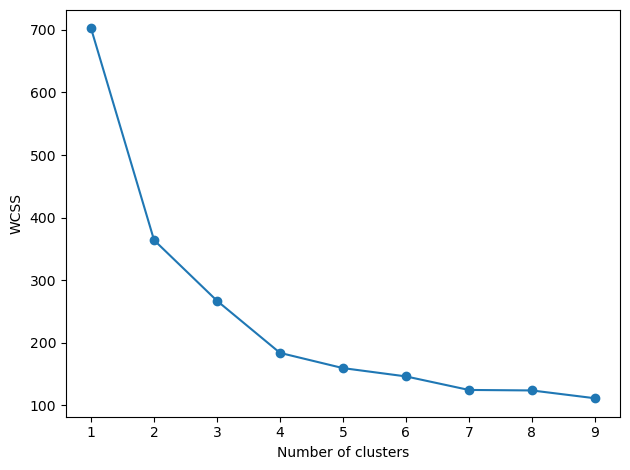

In [67]:
#No of clusters identification

WCSS = []
for i in range(1, 10):
    km = KMeans(n_clusters=i, init='random', n_init=10, max_iter=300, random_state=0)
    km.fit(X)
    WCSS.append(km.inertia_)
plt.plot(range(1, 10), WCSS, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.tight_layout()
plt.show()

In [68]:
km = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300, tol=1e-04, random_state=0)

y_km = km.fit_predict(X)
print('Cluster classification:')
print(y_km)

print(f'WCSS: {km.inertia_:.2f}')

Cluster classification:
[2 2 3 2 2 2 2 3 3 2 2 0 3 3 1 1 0 2 3 3 0 0 2 0 1 2 2 2 2 2 1 2 2 0 3 2 2
 0 3 1 1 0 1 0 2 2 1 2 2 2 2 1 2 1 2 2 0 0 0 0 3 3 3 2 2 2 3 2 2 2 2 0 1 3
 3 2 3 3 0 0 3 3 3 0 2 1 3 0 1 2 2 2 3 2 2 0 2 1 2 3 0]
WCSS: 183.99


C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


After k = 4, the curve begins to flatten greatly thus the amount of clusters based on K-Means is 4. Just to ensure that this figure is accurate, we look towards silhoette plot to determine whether 4 clusters are accuarte. 

Silhouette Plot

C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

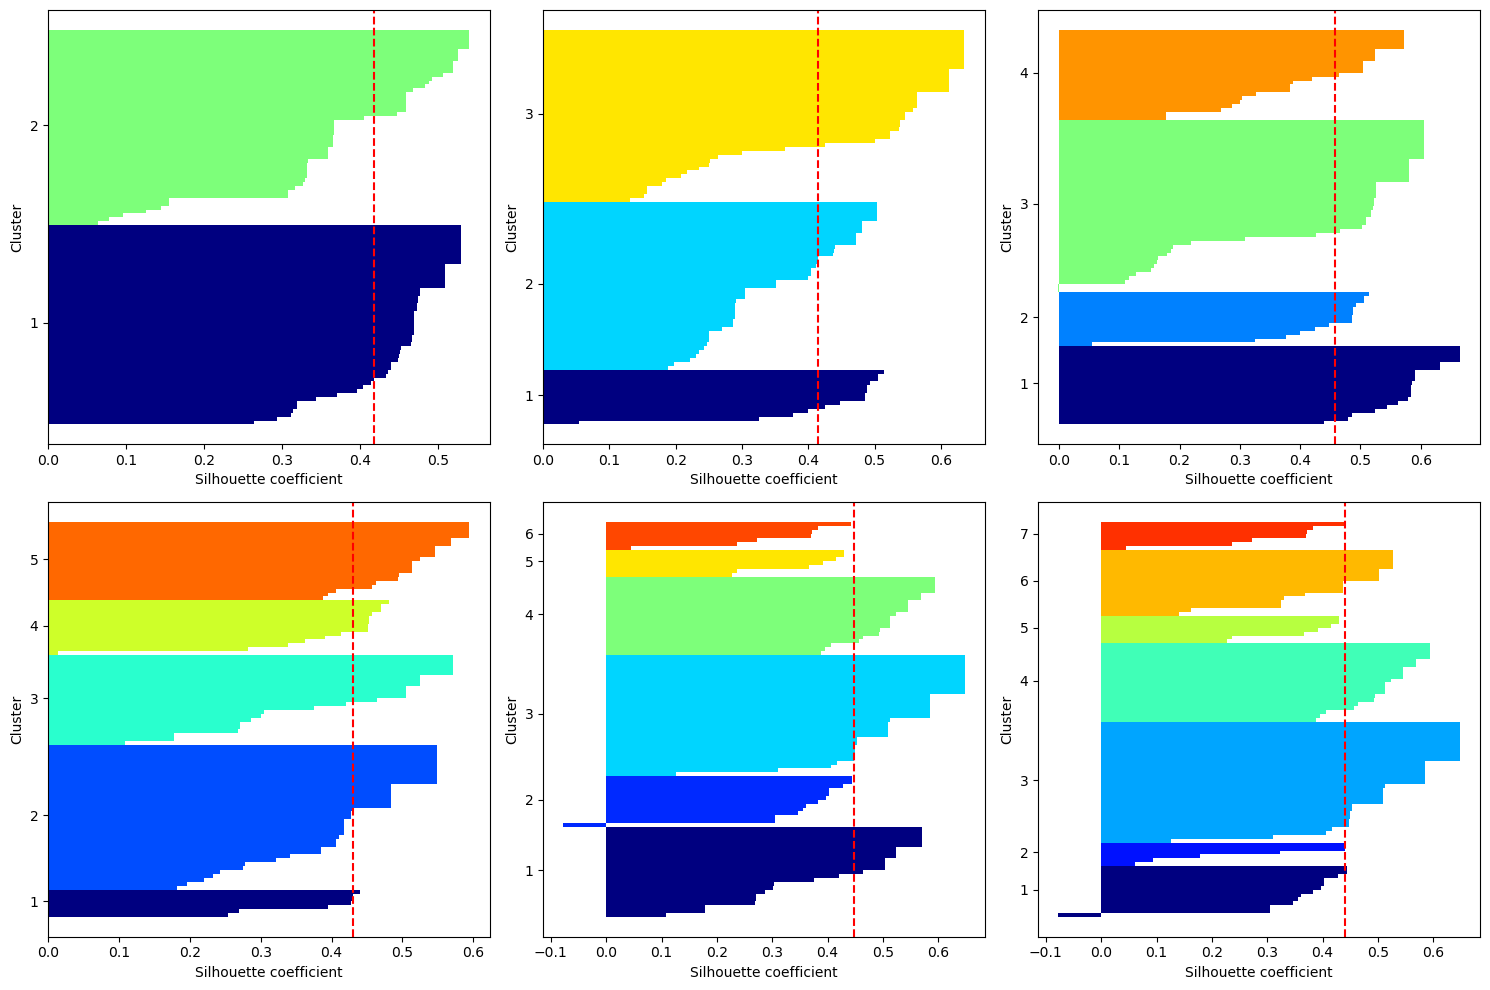

In [69]:
from matplotlib import cm

plt.figure(figsize=(15, 10))
plt.subplots_adjust(hspace=0.5)

for i in range(2, 8):
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=300, random_state=0)
    y_km = km.fit_predict(X)

    ax = plt.subplot(2, 3, i-1)
    cluster_labels = np.unique(y_km)
    n_clusters = cluster_labels.shape[0]
    silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')
    y_ax_lower, y_ax_upper = 0, 0
    yticks = []
    for i, c in enumerate(cluster_labels):
        c_silhouette_vals = silhouette_vals[y_km == c]
        c_silhouette_vals.sort()
        y_ax_upper += len(c_silhouette_vals)
        color = cm.jet(float(i) / n_clusters)
        plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, 
                 edgecolor='none', color=color)

        yticks.append((y_ax_lower + y_ax_upper) / 2.)
        y_ax_lower += len(c_silhouette_vals)
    
    silhouette_avg = np.mean(silhouette_vals)
    plt.axvline(silhouette_avg, color="red", linestyle="--") 

    plt.yticks(yticks, cluster_labels + 1)
    plt.ylabel('Cluster')
    plt.xlabel('Silhouette coefficient')

plt.tight_layout()
plt.show()

The silhouette plots show us that the highest silhouette coefficient obtained had 4 clusers thus our above assumption of 4 clusters was accuarate. 

Hierachal Clustering 

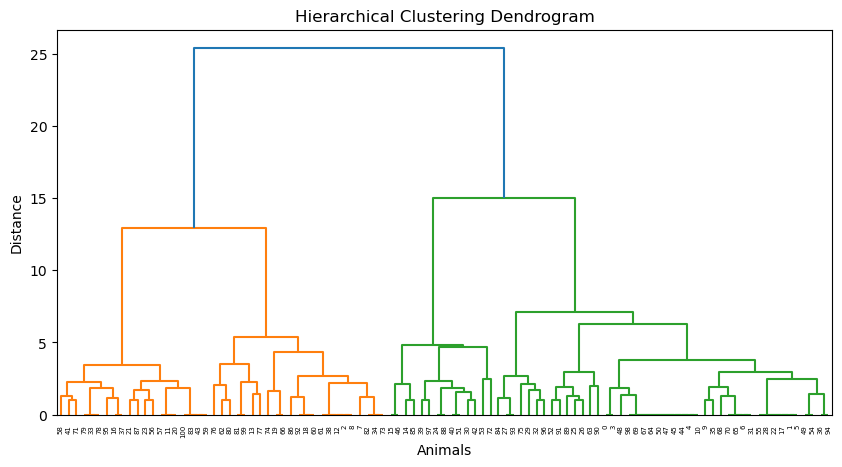

In [71]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Use all animal features except animal name
X = df_ZOO.iloc[:, 1:]

# Create linkage matrix using Ward linkage
linkage_matrix = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 5))

dendrogram(linkage_matrix)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Animals")
plt.ylabel("Distance")

plt.show()

The dendogram shows 4 major groups thus strengthening our conclusion of having 4 clusters of animals in the data. 

In [72]:
db = DBSCAN(eps=1.5, min_samples=3, metric='euclidean')

y_db = db.fit_predict(X)
y_db

array([ 0,  0,  1,  0,  0,  0,  0,  1,  1,  0,  0,  2,  1,  3,  4,  4,  2,
        0,  1,  5,  2,  2,  0,  2,  6,  7,  7,  8,  0,  8,  6,  0,  8,  2,
        1,  0,  0,  2,  1,  6,  6,  2,  6,  2,  0,  0,  4,  0,  0,  0,  0,
        6,  7, -1,  0,  0,  2,  2,  2,  2,  1,  1, -1,  0,  0,  0,  5,  0,
        0,  0,  0,  2, -1,  1,  5, -1, -1,  3,  2,  2, -1,  3,  1,  2,  8,
        4,  1,  2,  6,  7, -1,  7,  1,  8,  0,  2,  8,  6,  0,  3,  2])

DBSCAN with min_samples = 3 produced 9 clusters, along with a small number of unclassified points labeled as -1. Epsilon was chosen so that there would be minimal white noise points, allowing most anmals to be successfully assigned to meaningful clusters. Compared to k-means, DBSCAN identified clusters based on local density and structural similarity rather than grouping into spherical groups. This may better reflt the topological relationships among animals. Further, DBSCAN was able to identify potential outliers that did not strongly belong to ay cluster which provides a more flexible interpretation of animal relationships. 

In [79]:
df_ZOO['Cluster'] = y_db

grouped = df_ZOO.groupby('Cluster')[0].apply(list)

for cluster, animals in grouped.items():
    print(f"\nCluster {cluster}:")
    print(animals)


Cluster -1:
['octopus', 'pitviper', 'scorpion', 'sealion', 'seasnake', 'slowworm', 'tortoise']

Cluster 0:
['aardvark', 'antelope', 'bear', 'boar', 'buffalo', 'calf', 'cavy', 'cheetah', 'deer', 'elephant', 'giraffe', 'goat', 'hamster', 'hare', 'leopard', 'lion', 'lynx', 'mink', 'mole', 'mongoose', 'opossum', 'oryx', 'platypus', 'polecat', 'pony', 'puma', 'pussycat', 'raccoon', 'reindeer', 'vole', 'wolf']

Cluster 1:
['bass', 'carp', 'catfish', 'chub', 'dogfish', 'haddock', 'herring', 'pike', 'piranha', 'seahorse', 'sole', 'stingray', 'tuna']

Cluster 2:
['chicken', 'crow', 'dove', 'duck', 'flamingo', 'gull', 'hawk', 'kiwi', 'lark', 'ostrich', 'parakeet', 'penguin', 'pheasant', 'rhea', 'skimmer', 'skua', 'sparrow', 'swan', 'vulture', 'wren']

Cluster 3:
['clam', 'seawasp', 'slug', 'worm']

Cluster 4:
['crab', 'crayfish', 'lobster', 'starfish']

Cluster 5:
['dolphin', 'porpoise', 'seal']

Cluster 6:
['flea', 'gnat', 'honeybee', 'housefly', 'ladybird', 'moth', 'termite', 'wasp']

Cluster

In [80]:
kmeans = KMeans(n_clusters=4, random_state=0)

df_ZOO['Cluster'] = kmeans.fit_predict(X)

C:\Users\aryel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [81]:
grouped = df_ZOO.groupby('Cluster')

for cluster_num in grouped.groups:
    print(f"\nCluster {cluster_num}")
    print(grouped.get_group(cluster_num)[0].tolist())


Cluster 0
['aardvark', 'antelope', 'bear', 'boar', 'buffalo', 'calf', 'cavy', 'cheetah', 'deer', 'elephant', 'frog', 'frog', 'giraffe', 'girl', 'goat', 'gorilla', 'hamster', 'hare', 'leopard', 'lion', 'lynx', 'mink', 'mole', 'mongoose', 'newt', 'opossum', 'oryx', 'platypus', 'polecat', 'pony', 'puma', 'pussycat', 'raccoon', 'reindeer', 'sealion', 'squirrel', 'toad', 'tortoise', 'tuatara', 'vole', 'wallaby', 'wolf']

Cluster 1
['bass', 'carp', 'catfish', 'chub', 'clam', 'dogfish', 'dolphin', 'haddock', 'herring', 'pike', 'piranha', 'pitviper', 'porpoise', 'seahorse', 'seal', 'seasnake', 'seawasp', 'slowworm', 'slug', 'sole', 'stingray', 'tuna', 'worm']

Cluster 2
['chicken', 'crow', 'dove', 'duck', 'flamingo', 'fruitbat', 'gull', 'hawk', 'kiwi', 'lark', 'ostrich', 'parakeet', 'penguin', 'pheasant', 'rhea', 'skimmer', 'skua', 'sparrow', 'swan', 'vampire', 'vulture', 'wren']

Cluster 3
['crab', 'crayfish', 'flea', 'gnat', 'honeybee', 'housefly', 'ladybird', 'lobster', 'moth', 'octopus', 

## KMEANS

After determining that 4 clusters of animals are needed, we presented the clusters by listing the animal names in each group. 
### **1. Cluster 0** 
Cluster 0 obtains mainly mammals, amphibians and reptiles where these animals tend to share backbone, breathing, tails and on land movement

### **2. Cluster 1** 
Cluster 1 containes aquatic animals which containes fish, marine animals and aquatic animals. Features they share include fins, lack of legs and are not airborne. 

### **3. Cluster 2** 
Cluster 2 mainly include birds and flying animals. Some features which may be shared are feathers, eggs and are airborne

### **4. Cluster 3** 
Cluster 3 seems to list invertibrates and insects. Some characteristics that may be shared are having no backbone, small size, multiple legs and having exoskeletons. 

## DBSCAN 
Compared to k-means clustering, DBSCAN obtained 9 clusters of animals and a small outlier group. The clusters corresponnd to mammals, fish, birds, insects, marine invertebrae and amphibians/reptiles. These groups indicate that DBSCAN successfully grouped animals together according to shared structural and biological characteristics thus portraying a more accurate animal grouping comapred to k-means. DBSCAN produced more biologically meaningful density-based groups and allowed for outliers instead of forcing every animal in a group.  
### **1. Cluster 0** 
Cluster 0 mostly contained large mammals and land mammals with features such as fur, warm-blooded traits and four-legged motion. 

### **2. Cluster 1** 
Cluster 1 mainly contained types of fish and share features like aquatic structure, fins, gills and streamlined body plans. 

### **3. Cluster 2** 
Cluster 2 conatained types of birds with shared features being feathers, egg laying and wing structures. 

### **4. Cluster 3** 
Cluster 3 are mainly soft-bodied invertebrates where these creatures lacked rigid skeletal structures and have simple body plans. 

### **5. Cluster 4** 
Cluster 4 had mainly crustaceans and marine arthropods and were grouped together due to having similar features like exoskeletons and segmented bodies.

### **6. Cluster 5** 
Cluster 5 are marine mammals; mammals but adapted for aquatic environments. 

### **7. Cluster 6** 
Cluster 6 are insects with shared traits like exoskeletons, six legs and wing/body segmentation.  

### **8. Cluster 7** 
Cluster 7 containes amphibians/reptiles which shared semi-aquatic adaptations, ectothermic traits and body structures that change. 

### **9. Cluster 8**
Cluster 8 are primates and were probably separated due to locomotion differences and jumping adaptations. 

### **10. Cluster -1** 
The animals listed here have unique structural characteristics. Since these characteristics were unusual instead of forcing the animals in arbitrary groups, it just considered them outliers.  